## Pupil Gluing Characterisation 🖌️

This notebook:
1. Calculates the Zernike coefficients on two separate starphire plates
2. Calculates the Zernike coefficients on the glued starphire setup

It is helpful to the phase retrieval process that data taken for the non-glued plates and glued setup have the same orientation.

Existing system aberrations are loaded and can be calculated using System_Aberrations.ipynb.

Data on two ~1/2 $\lambda$ plates from Alan Fry, with an **UPDATE** that these plates have gone through delamination. 
________________________________________________________________________________________________
**NOTE (on data orientation)**: When modelling dLux layers (aberrated apertures, transmissive layers, etc) - they are orientated w.r.t wavefront POV in direction of propagation. In our setup, the data collected has two orientation flips:
1. BFS-U3-200S6M flips image upside down from propagation direction POV (and stores it like this too)
2. The pupil plane is focused by a second OAP which reflects propgagtion direction and in-turn flips left-right (and it stores it like this too)

i.e. total effect is that data is flipped about origin.
________________________________________________________________________________________________

In [1]:
import dLux as dl
import dLux.utils as dlu

import jax.numpy as jnp
import numpy as np
import jax.random as jr
import jax.scipy as jsp
from jax import vmap  
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_disable_jit', False)


import zodiax as zdx
import optax
from tqdm.notebook import tqdm
# from tqdm import tqdm

from skimage.io import imread
from skimage.filters import window
import skimage as ski
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm

from src.PhaseRetrieval import OptimManager, JointOptimManager, PointSource, TransmissiveLayer

import os
import pickle

plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'upper' # true reading of array
plt.rcParams['figure.dpi'] = 72
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15

# data_dir = "/Volumes/MORGANA1/snert/gpir9156/toliman/"
data_dir = "/import/morgana1/snert/gpir9156/toliman/"
# data_dir = "/media/morgana2/gpir9156/toliman/"


# Detector response (gamma curve)
alpha = np.load(data_dir+"detector/80us_detector/ALPHA_norm.npy")
beta = np.load(data_dir+"detector/80us_detector/BETA_norm.npy")
gamma = np.load(data_dir+"detector/80us_detector/GAMMA_norm.npy")


import matplotlib as mpl
inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
bwr = mpl.colormaps["bwr"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
bwr.set_bad("k", 0.5)

In [2]:
print(jax.lib.xla_bridge.get_backend().platform)

cpu


/tmp/ipykernel_1291232/582351387.py:1: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(jax.lib.xla_bridge.get_backend().platform)


### System Parameters

In [3]:
# ------- Physical Parameters ---------------------------------------------------------------------#
aperture_npix = 512           # Number of pixels across the aperture
aperture_diameter = 122e-3    # (m) slightly smaller for mask cap
spider_width = 20e-3          # Spider width (m)
spider_angle =270             # Spider angle (degrees), clockwise, 0 is spider pointing vertically up
coords = dlu.pixel_coords(npixels=aperture_npix, diameter=aperture_diameter)
circle = dlu.circle(coords=coords, radius=aperture_diameter/2) 

# Observations wavelengths (bandpass of 530-640nm)
red_laser_wl =  635e-09  # for laser data
green_laser_wl = 520e-09  # for laser data
wf_npixels = aperture_npix  # Number of pixels across the wavefront
wf_diam = aperture_diameter             # Diameter of initial wavefront to propagate wavefront (m)

# Detector parameters (BFS-U3-200S6-BD)
BFS_px_sep = 2.4e-6 *1e3        # pixel separation (mm)
f_det = 1338 # 1300#1350                    # Focal length from OAP2 to detector (mm) 
px_ang_sep = 2*np.arctan( (BFS_px_sep/2)/f_det ) # angular sep between pixels (rad)

# Simulated Detector
psf_npix = 40                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)             # half window sz of cropped data
oversample = 1                 # Oversampling factor for the PSF
psf_pixel_scale = dlu.rad2arcsec(px_ang_sep) # arcsec (to match detector plate scale) 80e-4 


### Simulated Setup

In [4]:
# # In the setup, we have a fiber source. 
# # Can model the intensity distribution using a Guassian or can just measure it directly
# # Measuring directly also captures any mirror imperfections hindering transmission
# intensity_dist = np.load(data_dir+"intensity/15_07_intensity_img_stack.npy")[0,:]
# data = np.flip(intensity_dist)

# manual_lim = [1363,4203,386,3214]
# data = data[manual_lim[2]:manual_lim[3], manual_lim[0]:manual_lim[1]]
# data = (data - data.min())/(data.max()-data.min())

# blurred = ski.filters.gaussian(data, sigma=(120, 120))

# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.imshow(data)
# plt.title("Data - pre-focus")
# plt.colorbar()
# plt.subplot(1,3,2)
# plt.imshow(blurred)
# plt.title("Data blurred")
# plt.colorbar()
# plt.subplot(1,3,3)
# intensity_dist = resize(blurred, (aperture_npix, aperture_npix))
# intensity_dist = (intensity_dist - intensity_dist.min())/(intensity_dist.max()-intensity_dist.min()) # re-map from 0-1
# plt.title("Blurred re-sized")
# plt.imshow(intensity_dist)
# plt.colorbar()


Load in directly from work in System_Aberrations notebook

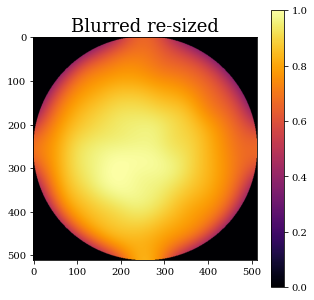

In [5]:
intensity_dist = jnp.load(data_dir+"intensity/24_3_25.npy")
plt.figure(figsize=(5,5))
plt.title("Blurred re-sized")
plt.imshow(intensity_dist)
plt.colorbar()

#### System Aberrations 

We have an imperfect system. Load in the system aberrations (calculated using System_Aberrations.ipynb)

In [6]:
# would have to run new sys analysis on flipped data
# f_aberr = "data/spider/retrieval_results/16_09_mean_coeffs_combined.npy"
f_aberr = "data/spider/retrieval_results/12_08_2025/system_coeffs_dict.pkl"

syst_noll = jnp.arange(4, 15) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
# syst_coeffs = jnp.load(f_aberr)
syst_coeffs = pickle.load(open(f_aberr, "rb"))["value"]
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))


System Coefficients (noll [ 4  5  6  7  8  9 10 11 12 13 14]): [-1.84e-08 -1.00e-09 -1.52e-08  9.40e-09  5.60e-09 -2.24e-08 -4.20e-09
  3.56e-08 -1.60e-09  3.80e-09 -1.12e-08]


Plate + Spider setup simulated

Text(0.5, 1.0, 'Spider 180')

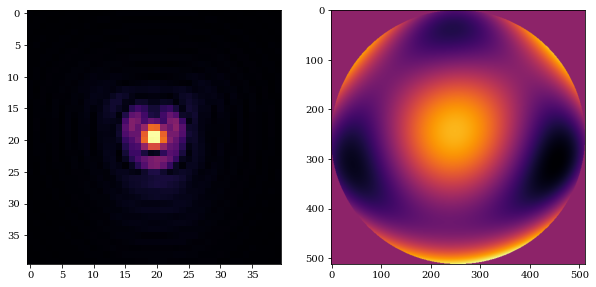

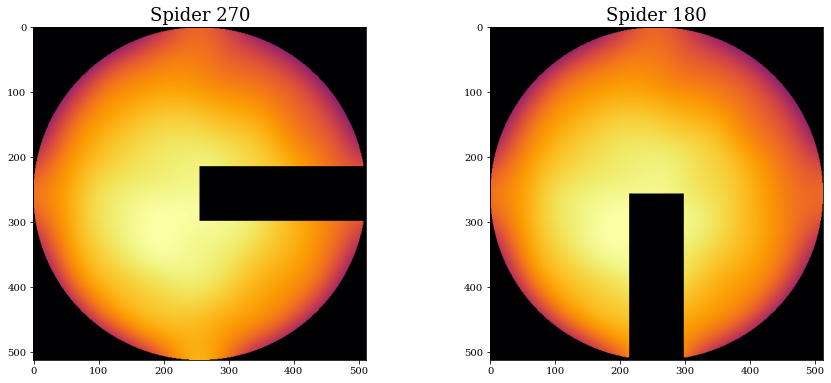

In [7]:
# Zernike aberrations
zernike_indicies = jnp.arange(4, 21) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)

optical_systems = []
transmissions = []

# Using PointSources instead of single PointSource object to overcome float grad issue when solving for flux
# green_src = dl.PointSources(wavelengths=[green_laser_wl], flux =jnp.asarray([1e8],dtype=float))
# red_src = dl.PointSources(wavelengths=[red_laser_wl], flux =jnp.asarray([1e8],dtype=float))
green_src = PointSource(wavelengths=[green_laser_wl], flux =jnp.asarray([1e9],dtype=float))
red_src = PointSource(wavelengths=[red_laser_wl], flux =jnp.asarray([1e9],dtype=float))

spider_angles = [270, 180] #0deg is spider pointing vertically up, rotates CW from 0deg
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', TransmissiveLayer(transmission=transmission, normalise=False)), #rotable spider
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]

    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]
# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = jnp.flip(optics.propagate_mono(green_laser_wl))
plt.subplot(1,2,1)
plt.imshow(psf**0.5)
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(optics_sp270.spider.transmission*optics_sp270.intensity.transmission)
plt.title("Spider 270")
plt.subplot(1,2,2)
plt.imshow(optics_sp180.spider.transmission*optics_sp180.intensity.transmission)
plt.title("Spider 180")

### Load in single Starphire data

#### Phase Retrieval

### Lets loop this

#### Starphire 1

In [8]:
# Location on detector 
row_start, col_start = 1910, 2920 # Start coord of window on det where data was taken
row_len, col_len = 130, 128   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_0deg_red_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_90deg_red_80us_0gain_img_stack_batch_0.npy",
    
]
labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_0deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_90deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
]
still_frame_idxs = [
    0, 0, 0, 0 # find_still_frame.py
]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck


In [9]:
save_dir = "data/non_glued/12_08_2025/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

plate_name = "plate1"

Scale data and apply non-linear correction

In [10]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1,3])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


Jointly fit plate WFE over different spider configurations and over time. Repeat for different WL data (to capture potential chromaticity don't jointly fit WL).

In [10]:
params = [
    "aperture.coefficients",
    "spider.rotation",
    "source.position",
    "source.flux", 
    ]


optimisers = [
            optax.adam(learning_rate=1e-10),
            optax.adam(learning_rate=1e-4),
            optax.adam(learning_rate=1e-8),
            optax.adam(learning_rate=1e6),
              ]

In [20]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [21]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=1500)

Loss:   0%|          | 0/1500 [00:00<?, ?it/s]

In [23]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/non_glued/12_08_2025/plate1_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/non_glued/12_08_2025/plate1_red_90deg_stored_params_dict.pkl


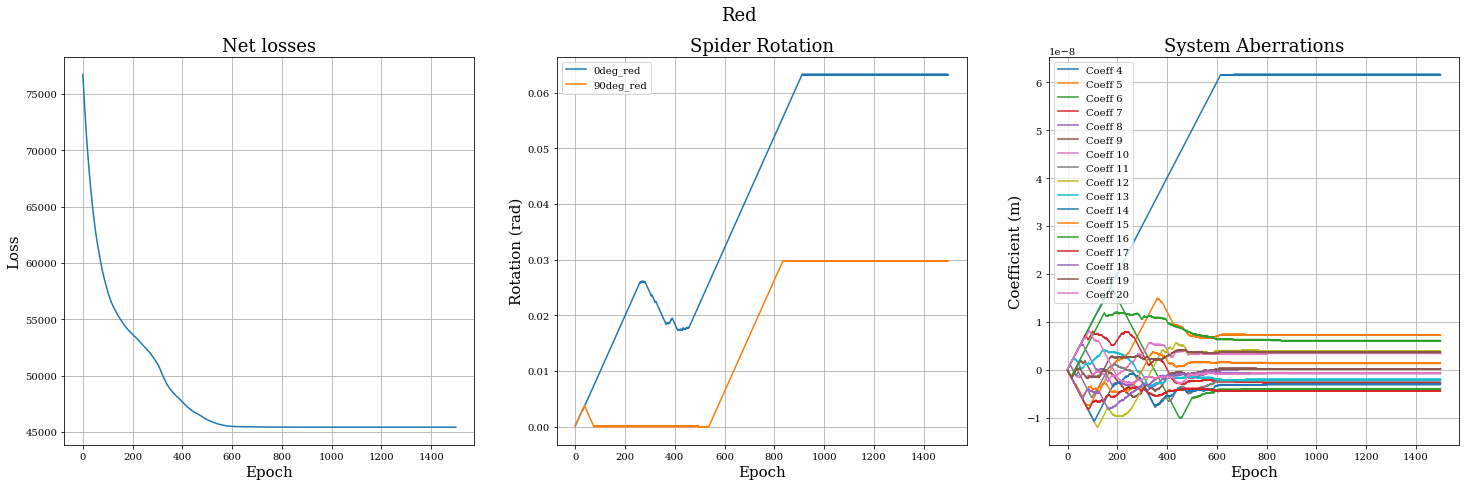

In [24]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

Save figures for each model fit, for both configs

In [25]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [26]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    plt.tight_layout()
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

Summary statistics 

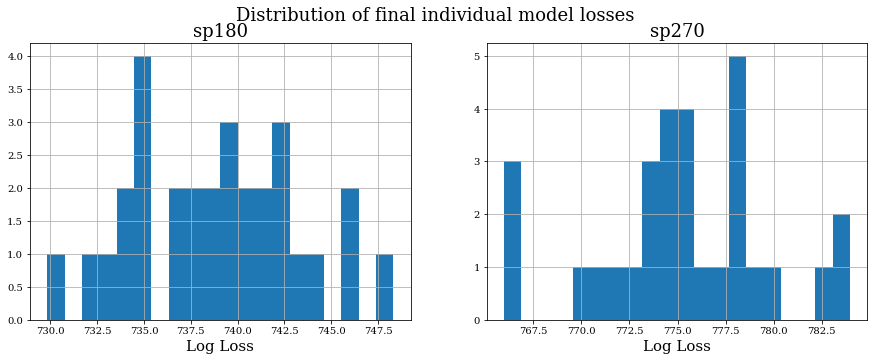

In [27]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [28]:
# calc CRLB and save coeffs + associated uncertainties  
# called AFTER optimisation (i.e. evaluated at MLE)
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [crlb.max(axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 30 frames


/tmp/ipykernel_1230460/3362112381.py:5: RuntimeWarning: All-NaN slice encountered
  CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)


red RMS WFE: 0.099lambda
Mean RMS WFE: 0.099lambda


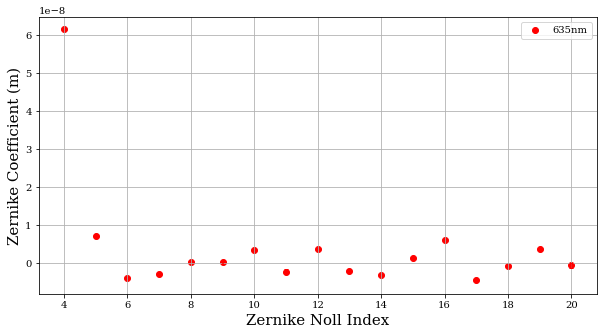

In [29]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i],ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

#### Starphire 2

In [11]:
img_fnames = [
    # "non_glued/14_04_2025/14_04_plate2_0deg_green_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate2_0deg_red_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate2_90deg_red_80us_0gain_img_stack_batch_0.npy",
    
]
labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_0deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate1_90deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
]
still_frame_idxs = [
    0, 0, 0, 0 # find_still_frame.py
]
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck

In [12]:
plate_name = "plate2"

In [13]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1,3])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


In [14]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [15]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=1500)


Loss:   0%|          | 0/1500 [00:00<?, ?it/s]

In [17]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/non_glued/12_08_2025/plate2_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/non_glued/12_08_2025/plate2_red_90deg_stored_params_dict.pkl


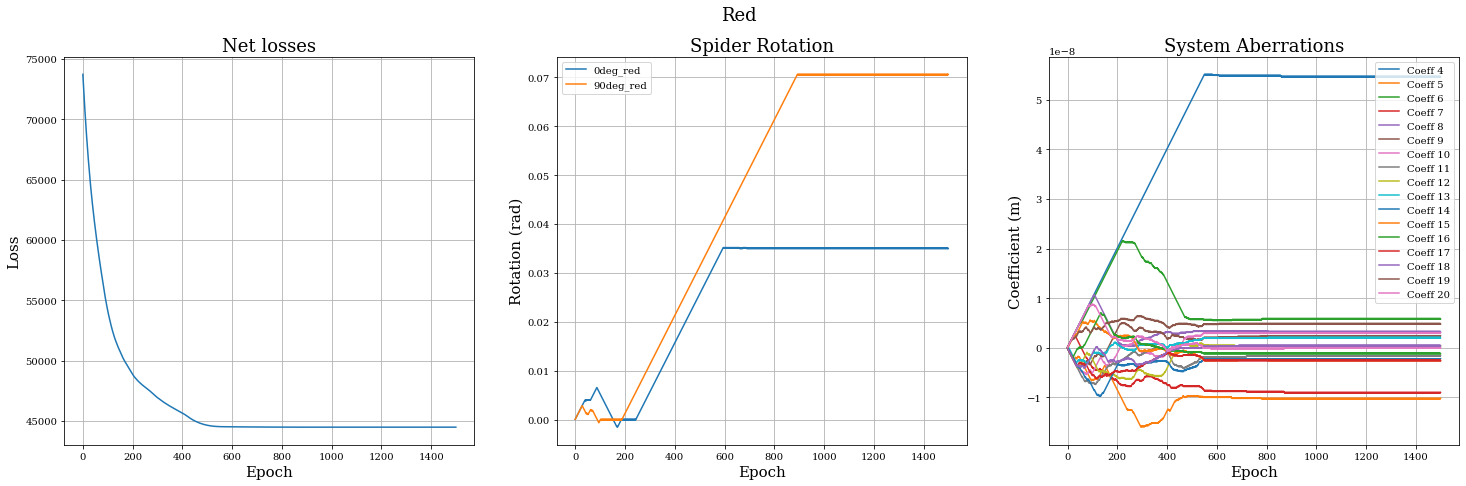

In [18]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

In [19]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [20]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    plt.tight_layout()
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

Summary stats

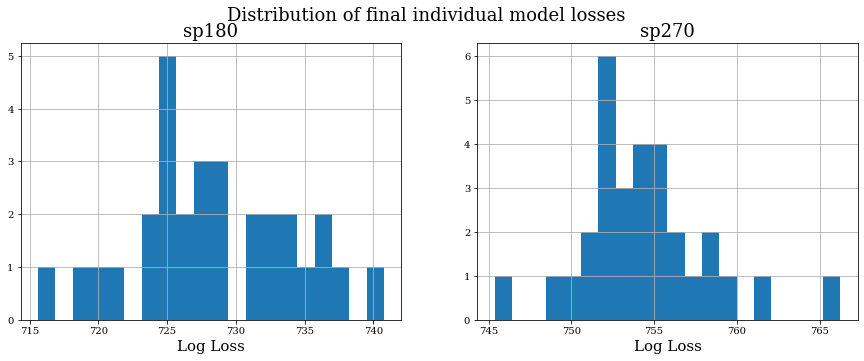

In [21]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [22]:
# calc CRLB and save coeffs + associated uncertainties  
# called AFTER optimisation (i.e. evaluated at MLE)
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [crlb.max(axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 30 frames


/tmp/ipykernel_1291232/3362112381.py:5: RuntimeWarning: All-NaN slice encountered
  CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)


red RMS WFE: 0.090lambda
Mean RMS WFE: 0.090lambda


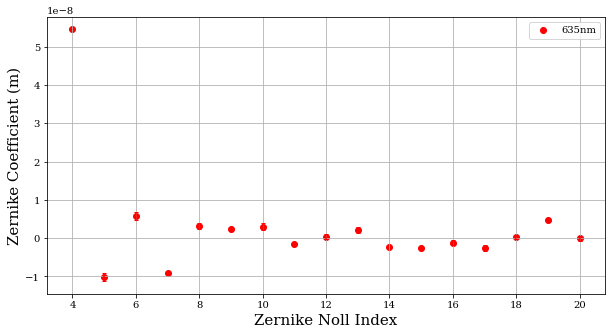

In [24]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i],ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

______________________________________________________________________________________________________________________________________________________________________________________________

Compare Plates (to each other and to 4_25, before they were delaminated for a second time)

In [ ]:
# # Calc fit statistics
# coeff_dir = [["data/non_glued/21_03_25/plate5","data/non_glued/14_04_2025/red_plate1"], 
#               ["data/non_glued/21_03_25/plate6","data/non_glued/14_04_2025/plate2"] ]
# plate_name = ["plate1", "plate2"]
# m = ['o', '*']
# lab = [" "," post delam"]


# plt.figure(figsize=(10,13))
# for i in range(len(coeff_dir)):
#     plt.subplot(2,1,i+1)
#     plt.grid()

#     for k in range(2):
#         green_coeffs = np.load(coeff_dir[i][k]+"_green_aperture_coeffs.npy")
#         red_coeffs = np.load(coeff_dir[i][k]+"_red_aperture_coeffs.npy") 
#         mean_green = np.mean(green_coeffs, axis=0) #teehee
#         mean_red = np.mean(red_coeffs, axis=0)
#         stdev_green, stdev_red = np.std(green_coeffs, axis=0), np.std(red_coeffs, axis=0)

#         # WFE calc excluding piston, tip and tilt
#         wf_errs = []

#         labels = ['green', 'red']
#         stdevs = [stdev_green, stdev_red]
#         for j,coeffs in enumerate([mean_green, mean_red]):
#             if 'red' in labels[j]:
#                 wl = red_laser_wl
#                 colour = 'r'
#             elif 'green' in labels[j]:
#                 wl = green_laser_wl
#                 colour = 'g'
#             else:
#                 ValueError("Unknown Wavelength")

#             plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm"+lab[k], c=colour, marker=m[k])
#             plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[j],ecolor=colour, capsize=2,linestyle='')

#             RMS_wf_err = ((coeffs**2).sum())**0.5

#             print("{}{}:{} RMS WFE: {:.3f}lambda".format(plate_name[i], lab[k],labels[j], RMS_wf_err/wl))
#             wf_errs.append(RMS_wf_err/wl) 

#         plt.xlabel("Zernike Noll Index")
#         plt.ylabel("Zernike Coefficient (m)")
#         plt.title(plate_name[i])
#         plt.legend()


#         # print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))


Image plane comparison

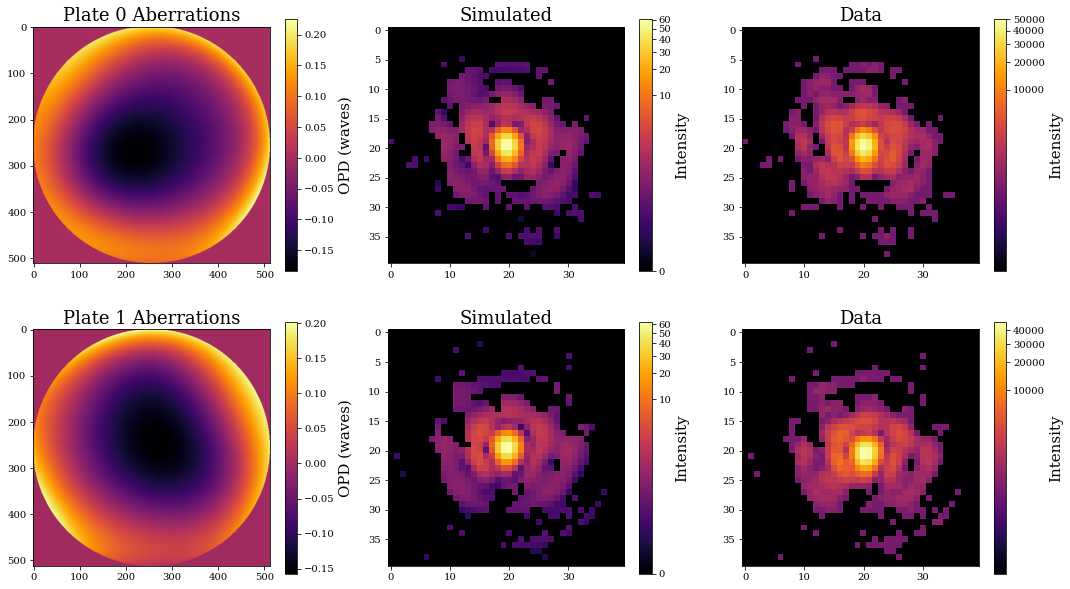

In [26]:
# Pick single orientation + wl to show this (position+spider rotation assumed unchanged here - looking for general structure)

img_fnames = [ # 1 per plate. starphire 1 followed by 2
    "non_glued/12_08_2025/12_08_2025_plate1_0deg_red_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_08_2025/12_08_2025_plate2_0deg_red_80us_0gain_img_stack_batch_0.npy",
] 
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])

coeffs_dir = [
            "data/non_glued/12_08_2025/plate1_red_coeffs_dict.pkl", 
            "data/non_glued/12_08_2025/plate2_red_coeffs_dict.pkl",
]

plt.figure(figsize=(18,10))
subplt_it = 1
for i, dir in enumerate(coeffs_dir):
    mean_coeffs = pickle.load(open(dir, 'rb'))['value']
    
    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mean_coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.subplot(2,3,subplt_it)
    plt.imshow(opd_basis/red_laser_wl)
    plt.title("Plate {} Aberrations".format(i))
    plt.colorbar(label="OPD (waves)")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")
    subplt_it += 1



______________________________________________________________________________________________________________________________________________________________________________________________

#### Glued plates



New syst aberrations (glued data taken three months after)

In [ ]:
# f_aberr = "data/spider/retrieval_results/3_01_mean_coeffs_combined.npy" #"data/spider/retrieval_results/17_12_mean_coeffs_combined.npy"
# f_aberr = "data/spider/retrieval_results/17_12_mean_coeffs_combined.npy"
# f_aberr = "data/spider/retrieval_results/28_07_25_mean_coeffs_combined.npy"
f_aberr = "data/spider/retrieval_results/31_07_25_mean_coeffs_jointly_fit.npy"



syst_noll = jnp.arange(4, 15) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
syst_coeffs = jnp.load(f_aberr)
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))

In [ ]:
# Re-create base models with new syst aberrations
psf_npix = 60                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)   # half window sz of cropped data
zernike_indicies = jnp.arange(4, 21) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', RotatingTransmissiveLayer(transmission=transmission, normalise=False)),
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]
    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]

# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = optics.propagate_mono(green_laser_wl)
plt.subplot(1,2,1)
plt.imshow(jnp.flip(psf)**0.5)
# plt.xlim([200,250])
# plt.ylim([200,250])
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd)


In [47]:
row_start, col_start = 1920, 2952 # Start coord of window on det where data was taken
row_len, col_len = 84, 88   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    "glued/28_07_2025/28_07_0deg_green_93us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_90deg_green_120us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_0deg_red_93us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_90deg_red_173us_0gain_img_stack_batch_0.npy",

]

labels = [
    "0deg_green",
    "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    "glued/28_07_2025/28_07_0deg_green_bckgnd_93us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_90deg_green_bckgnd_120us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_0deg_red_bckgnd_173us_0gain_img_stack_batch_0.npy",
    "glued/28_07_2025/28_07_90deg_red_bckgnd_173us_0gain_img_stack_batch_0.npy",
]
still_frame_idxs = [
    0, 0, 0, 0 # find_still_frame.py
]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
grab_frame_n = np.arange(0,imgs.shape[1],10)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck



In [149]:
save_dir = "data/glued/28_07_2025/"
plate_name = "glued"

In [150]:
params = [
    'aperture.coefficients',
    # 'spider.rotation',
    'source.position',
    'source.flux', 
    ]

learning_rate = 1e-9

optimisers = [
            optax.sgd(learning_rate=1e-20),
            # optax.sgd(learning_rate=1e-3),
            optax.adam(learning_rate=1e-7),
            optax.adam(learning_rate=1e7),
              ]


In [ ]:
psf_center_idx

In [ ]:
starphire1_coeffs, starphire1_pos = [], []
# plate_name = "plate1"

red_coeffs, green_coeffs = [],[] 
# 2 loops for 2 diff source colours
for i in range(2):
    data_idx = 2*i
    ###---------------------------- Re-init models ----------------------------###
    if i == 0:
        source = green_src
    else:
        source = red_src

    for frame_idx in grab_frame_n:
        instrument_sp180 = dl.Telescope(optics_sp180, ('source', source))
        instrument_sp270 = dl.Telescope(optics_sp270, ('source', source))

        sim_psfs = [instrument_sp180.model(), instrument_sp270.model()]
        norm_psfs = [PowerNorm(0.2, vmax=sim_psf.max(), vmin=sim_psf.min()) for sim_psf in sim_psfs]    

        ###------------------------------- Get Data -----------------------------###
        data_sp180 = imgs[data_idx][frame_idx,:,:] #assuming only two spider configs, given in order of increasing angle for each colour
        data_sp270 = imgs[data_idx+1][frame_idx,:,:]
        data_list = [data_sp180, data_sp270]
        scaled_data_list = []
        for j in range(len(data_list)):
            data = data_list[j]
            data = data - bckgnds[j]

            # Reverse-model detector response
            data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
            data = jnp.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

            # Scale intensity
            current_range = data.max() - data.min()
            new_range = sim_psfs[j].max() - sim_psfs[j].min()
            scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

            psf_center_idx = jnp.unravel_index(jnp.argmax(scaled_data, axis=None), scaled_data.shape)
            scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
            
            scaled_data_list.append(scaled_data)
        ###------------------------------- Phase Retrieval -----------------------------###
        configs = [instrument_sp180, instrument_sp270]
        optim, opt_state = zdx.get_optimiser(instrument_sp180, params, optimisers) # Needs to be iterable param (i.e. accessible via instrument class)

        progress_bar = tqdm(range(3000), desc='Loss: ')
        # progress_bar = tqdm(range(100), desc='Loss: ')


        # Run optimisation loop 
        net_losses, Coeffs, Positions_sp180, Positions_sp270, Fluxes, SpiderAngles= [],[],[],[],[],[]
        for j in progress_bar:
            grads = None
            net_loss = 0
            mean_coeff_grads, mean_position_grads, mean_flux_grads = None, None, None # to set initially in loop
            pos_grads = [] # update positional gradients separately (right now I've centered data based on brightest pixel
                            # but this is not a super robust method, so allow for source position difference)
            spider_grads = [] # acc for spider err rotation independently between configs
            for k in range(len(configs)):
                loss, grads = loss_fn_diff2(model = configs[k], data = scaled_data_list[k]) #loss_fn_poisson(model = configs[k], data = scaled_data_list[k])
                # loss, grads = loss_fn_poisson(model = configs[k], data = scaled_data_list[k])
                net_loss += loss 
                
                if k == 0:
                    mean_coeff_grads = grads.aperture.coefficients/len(configs)
                    mean_position_grads = grads.source.position/len(configs)
                    mean_flux_grads = grads.source.flux/len(configs)
                else:
                    mean_coeff_grads += grads.aperture.coefficients/len(configs)
                    mean_position_grads += grads.source.position/len(configs)
                    mean_flux_grads += grads.source.flux/len(configs)

                pos_grads.append(grads.source.position)
                spider_grads.append(grads.spider.rotation)

            grads = grads.set('aperture.coefficients', mean_coeff_grads)
            grads = grads.set('source.position', mean_position_grads)
            grads = grads.set('source.flux', mean_flux_grads)

            for k in range(len(configs)):
                grads = grads.set('source.position', pos_grads[k])
                grads = grads.set('spider.rotation', spider_grads[k])
                updates, opt_state = optim.update(grads, opt_state)
                configs[k] = zdx.apply_updates(configs[k], updates)

            net_losses.append(net_loss)
            Fluxes.append(configs[0].source.flux)
            Coeffs.append(configs[0].aperture.coefficients)
            Positions_sp180.append(configs[0].source.position)
            Positions_sp270.append(configs[1].source.position)
            SpiderAngles.append([configs[0].spider.rotation, configs[1].spider.rotation])

            progress_bar.set_postfix({'Loss (combined)': net_loss})

        ###---------------------------------- Plotting ---------------------------------###
        plt.figure(figsize=(18,18))
        plt.subplot(5,3,1)
        plt.plot(np.asarray(Positions_sp180)[:,0], label="Position X - sp180")
        plt.plot(np.asarray(Positions_sp180)[:,1], label="Position Y - sp180")
        plt.plot(np.asarray(Positions_sp270)[:,0], label="Position X - sp270")
        plt.plot(np.asarray(Positions_sp270)[:,1], label="Position Y - sp270")
        plt.title("Position")
        plt.legend()
        plt.subplot(5,3,2)
        arr_coeffs = np.asarray(Coeffs)
        for l in range(len(Coeffs[0])):
            label = "Coeff " + str(zernike_indicies[l])
            plt.plot(arr_coeffs[:,l], label=label)
        # plt.legend()
        plt.subplot(5,3,3)
        plt.plot(np.asarray(Fluxes))
        plt.title("Flux")
        plt.subplot(5,3,4)
        plt.plot(np.array(net_losses))
        ax = plt.gca()
        ax.set_title("Training History")
        ax.set_xlabel("Training Epoch")
        ax.set_ylabel("Poisson Log-Likelihood")

        it = 5
        for k, config in enumerate(configs):
            plt.subplot(5,3,it)
            opd = config.aperture.eval_basis()
            trans = config.spider.transmission
            plt.imshow(opd*trans, cmap='viridis')
            plt.title('Retrieved Aberrations')
            plt.colorbar()
            it+=1

        for k, config in enumerate(configs):
            scaled_data = scaled_data_list[k]
            instrument = config

            plt.subplot(5,3,it)
            norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
            plt.imshow(scaled_data, norm=norm_psf)
            plt.colorbar()
            plt.title('Data - '+labels[data_idx+k])
            it+=1

            plt.subplot(5,3,it)
            model_psf = instrument.model()
            current_range = model_psf.max() - model_psf.min()
            new_range = scaled_data.max() - scaled_data.min()
            model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
            norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
            mask = np.ones(scaled_data.shape)
            # mask[scaled_data < 0.01] = 0
            plt.imshow(model_psf*mask, norm=norm_psf)
            plt.title('Model')
            plt.colorbar()
            it+=1

            plt.subplot(5,3,it)
            resid = scaled_data - model_psf
            plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
            plt.colorbar()
            plt.title('Residuals')
            it+=1
    
        plt.subplot(5,3,it)
        spider_angles_arr = np.asarray(SpiderAngles)
        plt.plot(spider_angles_arr[:,0], label="config0")
        plt.plot(spider_angles_arr[:,1], label="config0")
        plt.title("Spider Angle")
        plt.ylabel("Rotation (rad)")

        color = 'green' if i == 0 else 'red'
        plt.savefig(save_dir + color + "_"+plate_name+"_frame" + str(frame_idx) + "_fit.png")
        plt.close()

        starphire1_coeffs.append(configs[0].aperture.coefficients) # identical coeffs for both configs
        starphire1_pos.append([configs[0].source.position, configs[1].source.position])

        if i == 0:
            green_coeffs.append(configs[0].aperture.coefficients)
            np.save(save_dir + plate_name+"_{}_green_aperture_coeffs.npy".format(frame_idx), np.asarray(configs[0].aperture.coefficients))
        else:
            red_coeffs.append(configs[0].aperture.coefficients)
            np.save(save_dir + plate_name+"_{}_red_aperture_coeffs.npy".format(frame_idx), np.asarray(configs[0].aperture.coefficients))

        print("Frame {} complete".format(frame_idx))

np.save(save_dir + plate_name+"_red_aperture_coeffs.npy", np.asarray(red_coeffs))
np.save(save_dir + plate_name+"_green_aperture_coeffs.npy", np.asarray(green_coeffs))


#### Re-run glued optimisation but with defocus included
Initialising with above coefficients should help the model converge correctly

In [ ]:
row_start, col_start = 1920, 2952 # Start coord of window on det where data was taken
row_len, col_len = 84, 88   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    "glued/31_07_2025/31_07_2025_0deg_green_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_0deg_red_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_90deg_red_80us_0gain_img_stack_batch_0.npy",

]

labels = [
    "0deg_green",
    "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    "glued/31_07_2025/31_07_2025_0deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_90deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_0deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
    "glued/31_07_2025/31_07_2025_90deg_red_bckgnd_80us_0gain_img_stack_batch_0.npy",
]
still_frame_idxs = [
    0, 0, 0, 0 # find_still_frame.py
]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
grab_frame_n = np.arange(0,imgs.shape[1],15)
print(grab_frame_n)
bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck



In [50]:
params = [
    'aperture.coefficients',
    # 'spider.rotation',
    'source.position',
    'source.flux', 
    ]


optimisers = [
            optax.adam(learning_rate=1e-9),
            # optax.adam(learning_rate=1e-3),
            optax.adam(learning_rate=1e-7),
            optax.adam(learning_rate=1e6),
              ]


In [ ]:
save_dir = "data/glued/31_07_2025/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

plate_name = "glued"

Load in previously retrieved coeffs as a model initialisation

In [52]:
init_red=np.load("data/glued/28_07_2025/glued_red_aperture_coeffs.npy")[0] # picking first frame result
init_green=np.load("data/glued/28_07_2025/glued_green_aperture_coeffs.npy")[0]

In [ ]:
starphire1_coeffs, starphire1_pos = [], []
# plate_name = "plate1"

red_coeffs, green_coeffs = [],[] 
# 2 loops for 2 diff source colours
for i in range(2):
    data_idx = 2*i
    ###---------------------------- Re-init models ----------------------------###
    if i == 0:
        source = green_src
        optics_sp180 = optics_sp180.set("aperture.coefficients", init_green)
        optics_sp270 = optics_sp270.set("aperture.coefficients", init_green)

    else:
        source = red_src
        optics_sp180 = optics_sp180.set("aperture.coefficients", init_red)
        optics_sp270 = optics_sp270.set("aperture.coefficients", init_red)

    for frame_idx in grab_frame_n:
        instrument_sp180 = dl.Telescope(optics_sp180, ('source', source))
        instrument_sp270 = dl.Telescope(optics_sp270, ('source', source))

        sim_psfs = [instrument_sp180.model(), instrument_sp270.model()]
        norm_psfs = [PowerNorm(0.2, vmax=sim_psf.max(), vmin=sim_psf.min()) for sim_psf in sim_psfs]    

        ###------------------------------- Get Data -----------------------------###
        data_sp180 = imgs[data_idx][frame_idx,:,:] #assuming only two spider configs, given in order of increasing angle for each colour
        data_sp270 = imgs[data_idx+1][frame_idx,:,:]
        data_list = [data_sp180, data_sp270]
        masks = []

        scaled_data_list = []
        for j in range(len(data_list)):
            data = data_list[j]
            data = data - bckgnds[j]
            m = jnp.ones(data.shape)
            m = m.at[data <= 255].set(np.nan)

            # Reverse-model detector response
            data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
            data = jnp.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

            # Scale intensity
            current_range = data.max() - data.min()
            new_range = sim_psfs[j].max() - sim_psfs[j].min()
            scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

            psf_center_idx = jnp.unravel_index(jnp.argmax(scaled_data, axis=None), scaled_data.shape)
            scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
            
            scaled_data_list.append(scaled_data)
            masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        ###------------------------------- Phase Retrieval -----------------------------###
        configs = [instrument_sp180, instrument_sp270]
        optim, opt_state = zdx.get_optimiser(instrument_sp180, params, optimisers) # Needs to be iterable param (i.e. accessible via instrument class)

        progress_bar = tqdm(range(3000), desc='Loss: ')
        # progress_bar = tqdm(range(100), desc='Loss: ')


        # Run optimisation loop 
        net_losses, Coeffs, Positions_sp180, Positions_sp270, Fluxes, SpiderAngles= [],[],[],[],[],[]
        for j in progress_bar:
            grads = None
            net_loss = 0
            mean_coeff_grads, mean_position_grads, mean_flux_grads = None, None, None # to set initially in loop
            pos_grads = [] # update positional gradients separately (right now I've centered data based on brightest pixel
                            # but this is not a super robust method, so allow for source position difference)
            spider_grads = [] # acc for spider err rotation independently between configs
            for k in range(len(configs)):
                # loss, grads = loss_fn_diff2(model = configs[k], data = scaled_data_list[k]) #loss_fn_poisson(model = configs[k], data = scaled_data_list[k])
                loss, grads = loss_fn_poisson(model = configs[k], data = scaled_data_list[k])
                net_loss += loss 
                
                if k == 0:
                    mean_coeff_grads = grads.aperture.coefficients/len(configs)
                    mean_position_grads = grads.source.position/len(configs)
                    mean_flux_grads = grads.source.flux/len(configs)
                else:
                    mean_coeff_grads += grads.aperture.coefficients/len(configs)
                    mean_position_grads += grads.source.position/len(configs)
                    mean_flux_grads += grads.source.flux/len(configs)

                pos_grads.append(grads.source.position)
                spider_grads.append(grads.spider.rotation)

            grads = grads.set('aperture.coefficients', mean_coeff_grads)
            grads = grads.set('source.position', mean_position_grads)
            grads = grads.set('source.flux', mean_flux_grads)

            for k in range(len(configs)):
                grads = grads.set('source.position', pos_grads[k])
                grads = grads.set('spider.rotation', spider_grads[k])
                updates, opt_state = optim.update(grads, opt_state)
                configs[k] = zdx.apply_updates(configs[k], updates)

            net_losses.append(net_loss)
            Fluxes.append(configs[0].source.flux)
            Coeffs.append(configs[0].aperture.coefficients)
            Positions_sp180.append(configs[0].source.position)
            Positions_sp270.append(configs[1].source.position)
            SpiderAngles.append([configs[0].spider.rotation, configs[1].spider.rotation])

            progress_bar.set_postfix({'Loss (combined)': net_loss})

        ###---------------------------------- Plotting ---------------------------------###
        plt.figure(figsize=(18,18))
        plt.subplot(5,3,1)
        plt.plot(np.asarray(Positions_sp180)[:,0], label="Position X - sp180")
        plt.plot(np.asarray(Positions_sp180)[:,1], label="Position Y - sp180")
        plt.plot(np.asarray(Positions_sp270)[:,0], label="Position X - sp270")
        plt.plot(np.asarray(Positions_sp270)[:,1], label="Position Y - sp270")
        plt.title("Position")
        plt.legend()
        plt.subplot(5,3,2)
        arr_coeffs = np.asarray(Coeffs)
        for l in range(len(Coeffs[0])):
            label = "Coeff " + str(zernike_indicies[l])
            plt.plot(arr_coeffs[:,l], label=label)
        # plt.legend()
        plt.subplot(5,3,3)
        plt.plot(np.asarray(Fluxes))
        plt.title("Flux")
        plt.subplot(5,3,4)
        plt.plot(np.array(net_losses))
        ax = plt.gca()
        ax.set_title("Training History")
        ax.set_xlabel("Training Epoch")
        ax.set_ylabel("Poisson Log-Likelihood")

        it = 5
        for k, config in enumerate(configs):
            plt.subplot(5,3,it)
            opd = config.aperture.eval_basis()
            trans = config.spider.transmission
            plt.imshow(opd*trans, cmap='viridis')
            plt.title('Retrieved Aberrations')
            plt.colorbar()
            it+=1

        for k, config in enumerate(configs):
            scaled_data = scaled_data_list[k]
            instrument = config

            plt.subplot(5,3,it)
            norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
            plt.imshow(scaled_data, norm=norm_psf)
            plt.colorbar()
            plt.title('Data - '+labels[data_idx+k])
            it+=1

            plt.subplot(5,3,it)
            model_psf = instrument.model()
            # current_range = model_psf.max() - model_psf.min()
            # new_range = scaled_data.max() - scaled_data.min()
            # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
            # norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
            # mask = np.ones(scaled_data.shape)
            # mask[scaled_data < 0.01] = 0
            norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
            plt.imshow(model_psf**masks[k], norm=norm_psf)
            plt.title('Model')
            plt.colorbar()
            it+=1

            plt.subplot(5,3,it)
            resid = scaled_data - model_psf
            plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
            plt.colorbar()
            plt.title('Residuals')
            it+=1
    
        plt.subplot(5,3,it)
        spider_angles_arr = np.asarray(SpiderAngles)
        plt.plot(spider_angles_arr[:,0], label="config0")
        plt.plot(spider_angles_arr[:,1], label="config0")
        plt.title("Spider Angle")
        plt.ylabel("Rotation (rad)")

        color = 'green' if i == 0 else 'red'
        plt.savefig(save_dir + color + "_"+plate_name+"_frame" + str(frame_idx) + "_fit.png")
        plt.close()

        starphire1_coeffs.append(configs[0].aperture.coefficients) # identical coeffs for both configs
        starphire1_pos.append([configs[0].source.position, configs[1].source.position])

        if i == 0:
            green_coeffs.append(configs[0].aperture.coefficients)
            np.save(save_dir + plate_name+"_{}_green_aperture_coeffs.npy".format(frame_idx), np.asarray(configs[0].aperture.coefficients))
        else:
            red_coeffs.append(configs[0].aperture.coefficients)
            np.save(save_dir + plate_name+"_{}_red_aperture_coeffs.npy".format(frame_idx), np.asarray(configs[0].aperture.coefficients))

        print("Frame {} complete".format(frame_idx))

np.save(save_dir + plate_name+"_red_aperture_coeffs.npy", np.asarray(red_coeffs))
np.save(save_dir + plate_name+"_green_aperture_coeffs.npy", np.asarray(green_coeffs))


Coefficient Comparsion

In [ ]:
save_dir

In [ ]:
# Calc fit statistics
coeff_dir = [
            "data/non_glued/14_04_2025/red_plate1", 
            "data/non_glued/14_04_2025/plate2",
            "data/glued/28_07_2025/glued",
            "data/glued/31_07_2025/glued",
            ]

plate_name = ["plate5", "plate6", "glued opt sans defocus", "glued"]

mosaic = """AC
            AC
            BD
            BD
        """
fig = plt.figure(constrained_layout=True, figsize=(15,8))
axes = fig.subplot_mosaic(mosaic,gridspec_kw={"wspace": 0.0,"hspace": 0.0},)  
axes_labels = ["A", "B", "C", "D"]


for i, alpha in enumerate(axes_labels):

    green_coeffs = np.load(coeff_dir[i]+"_green_aperture_coeffs.npy")
    red_coeffs = np.load(coeff_dir[i]+"_red_aperture_coeffs.npy") 
    mean_green = np.mean(green_coeffs, axis=0) #teehee
    mean_red = np.mean(red_coeffs, axis=0)
    stdev_green, stdev_red = np.std(green_coeffs, axis=0), np.std(red_coeffs, axis=0)

    # WFE calc excluding piston, tip and tilt
    wf_errs = []

    labels = ['green', 'red']
    stdevs = [stdev_green, stdev_red]
    for j,coeffs in enumerate([mean_green, mean_red]):
        if 'red' in labels[j]:
            wl = red_laser_wl
            colour = 'r'
        elif 'green' in labels[j]:
            wl = green_laser_wl
            colour = 'g'
        else:
            ValueError("Unknown Wavelength")

        axes[alpha].scatter(zernike_indicies, coeffs/wl, label=str(round(wl*1e9))+"nm", c=colour,marker='.')
        axes[alpha].errorbar(zernike_indicies, coeffs/wl, yerr=stdevs[j]/wl,ecolor=colour, capsize=2,linestyle='')

        RMS_wf_err = ((coeffs**2).sum())**0.5

        print("{}:{} RMS WFE: {:.3f}lambda".format(plate_name[i],labels[j], RMS_wf_err/wl))
        wf_errs.append(RMS_wf_err/wl) 

    axes[alpha].grid()
    axes[alpha].set_xlabel("Zernike Noll Index")
    axes[alpha].set_ylabel("Zernike Coefficient (waves)")
    axes[alpha].set_title(plate_name[i])
    axes[alpha].legend()


        # print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

Image Plane Comparison

1. Individual Plates

In [ ]:
# Pick single orientation + wl to show this (position+spider rotation assumed unchanged here - looking for general structure)

img_fnames = [ # 1 per plate. starphire 1 followed by 2
    "non_glued/14_04_2025/14_04_0deg_red_80us_0gain_img_stack_batch_0.npy",
    "non_glued/14_04_2025/14_04_plate2_0deg_red_80us_0gain_img_stack_batch_0.npy",
] 
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])

coeffs_dir = [
            "data/non_glued/14_04_2025/red_plate1_red_aperture_coeffs.npy", 
            "data/non_glued/14_04_2025/plate2_red_aperture_coeffs.npy",
]

plt.figure(figsize=(18,10))
subplt_it = 1
for i, dir in enumerate(coeffs_dir):
    coeffs = np.load(dir)
    mean_coeffs = coeffs.mean(axis=0)

    
    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mean_coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.subplot(2,3,subplt_it)
    plt.imshow(opd_basis/red_laser_wl)
    plt.title("Plate {} Aberrations".format(i))
    plt.colorbar(label="OPD (waves)")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")
    subplt_it += 1



In [ ]:
# Expected PSF from two aberrated plates
plate_rot = 0 # (deg)

mean_coeffs, stdevs = [], []
bases =[]
for i, dir in enumerate(coeffs_dir):
    coeffs = np.load(dir)
    mc = coeffs.mean(axis=0)

    mean_coeffs.append(mean_coeffs)
    stdevs.append(np.std(coeffs, axis=0))
    
    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mc, normalise=False)
    bases.append(plate_errors)

net_opd_basis = bases[0].eval_basis() + dlu.rotate(bases[1].eval_basis(), angle=np.pi/180*plate_rot)


new_optics_sp180 = optics_sp180.insert_layer(layer=("plate1", bases[0]), index=1)
new_optics_sp180 = new_optics_sp180.insert_layer(layer=("plate2", bases[1]), index=1)
instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(net_opd_basis/red_laser_wl)
plt.colorbar(label="OPD (waves)")
plt.title("Combined Plates (ideal)")
plt.subplot(1,2,2)
psf = instrument_sp180.model()
plt.imshow(psf, norm=PowerNorm(0.2))
plt.colorbar(label="Intensity")
plt.title("Simulated")


2. Glued Plates

In [ ]:
imgs = [jnp.asarray([np.flip(np.load(data_dir+"glued/31_07_2025/31_07_2025_0deg_red_80us_0gain_img_stack_batch_0.npy")) for img_fname in img_fnames]),
        jnp.asarray([np.flip(np.load(data_dir+"glued/28_07_2025/28_07_0deg_red_93us_0gain_img_stack_batch_0.npy")) for img_fname in img_fnames])
        ]


coeffs_list = [np.load("data/glued/31_07_2025/glued"+"_red_aperture_coeffs.npy"),np.load("data/glued/28_07_2025/glued"+"_red_aperture_coeffs.npy")]
# coeffs = np.load("data/glued/28_07_2025/glued"+"_red_aperture_coeffs.npy")

for i, coeffs in enumerate(coeffs_list):
    mean_coeffs = coeffs.mean(axis=0)

    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mean_coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.figure(figsize=(15,8))
    plt.subplot(2,3,1)
    plt.imshow(opd_basis/red_laser_wl)
    plt.title("Glued Plates Net Aberrations")
    plt.colorbar(label="OPD (waves)")

    plt.subplot(2,3,2)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")

    plt.subplot(2,3,3)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")

    opd_waves = opd_basis/red_laser_wl
    peak_valley = opd_waves.max() - opd_waves.min()
    print("P-V WFE: {}waves".format(peak_valley))



Visualise the impact to the toliman pupil

In [ ]:
mask.shape

In [ ]:
os

In [ ]:
# Optical system
import dLuxToliman as dLT

mask_path = "diffractive_pupil.npy"
mask = np.load(mask_path)
mask_layer = dl.BasisLayer(basis=np.array([mask]), coefficients=np.array([np.pi]), as_phase=True)

zernike_indices = np.arange(4,21)
os = dLT.TolimanOpticalSystem(        
        wf_npixels=mask.shape[0],
        psf_npixels=252,
        oversample=1,
        psf_pixel_scale=psf_pixel_scale,
        mask=mask_layer,
        noll_indices=zernike_indices,
        )

# syst_coeffs = np.load("data/glued/28_07_2025/glued"+"_red_aperture_coeffs.npy")
syst_coeffs = np.load("data/non_glued/14_04_2025/red_plate1_red_aperture_coeffs.npy")

syst_coeffs = syst_coeffs.mean(axis=0)

os_aberr = os.set("aperture.coefficients", syst_coeffs)

# Combined system
model = dl.Telescope(os, ('source', red_src))

print(model)

%matplotlib inline
psf = model.model()
psf_norm = PowerNorm(gamma=0.5)
pupil_basis = model.optics.pupil.eval_basis()
spider = model.optics.aperture.transmission
plt.figure(figsize=(20,8))
plt.subplot(1,3,1)
plt.imshow(pupil_basis*spider)
plt.title("Pupil + Spider")
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(psf,norm=psf_norm)
plt.title("PSF (no aberrations)")
plt.colorbar()
plt.subplot(1,3,3)
psf = dl.Telescope(os_aberr, ('source', red_src)).model()
psf_norm = PowerNorm(gamma=0.5)
plt.imshow(psf,norm=psf_norm)
plt.title("PSF (+ single fry plate aberrations)")
plt.colorbar()

________________________________________________________________________________________________________________________________________________
### MCMC
High dimensional problem - above optimisation is most likely getting stuck in local minimas. Lets send a walker to traverse this hilly terrain.

In [ ]:
import numpyro as npy
import numpyro.distributions as dist
from jax import device_count
import chainconsumer as cc
import pandas as pd
import pickle

print(device_count())

Initialise model + data

In [ ]:
# Start by modelling a single config, comparing to a single frame of data
instrument_sp180 = dl.Telescope(optics_sp180, ('source', green_src))
sim_psf = instrument_sp180.model()

# sanity check
plt.figure(figsize=(15,4))
plt.subplot(1,4,1)
plt.imshow(instrument_sp180.intensity.transmission*instrument_sp180.spider.transmission)
plt.title("Transmission")
plt.subplot(1,4,2)
plt.imshow(instrument_sp180.SystemAberrations.eval_basis())
plt.title("System Aberrations")
plt.subplot(1,4,3)
plt.imshow(sim_psf**0.2)
plt.title("Simulated PSF")
plt.colorbar()
plt.xlim([200,250])
plt.ylim([200,250])

data = imgs[0][0,:,:] # arbitrarily picking first frame
data = data - bckgnds[0]

# Reverse detector non-linearity
data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
data = np.power((data_remapped-np.flip(alpha_cropped))/np.flip(beta_cropped), (1/np.flip(gamma_cropped))) # apply inverse gamma fn 

# Scale intensity
current_range = data.max() - data.min()
new_range = sim_psf.max() - sim_psf.min()
scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psf.min()

# center and crop data around max
psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                            psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
plt.subplot(1,4,4)
plt.imshow(scaled_data**0.2)
plt.title("Data PSF")
plt.colorbar()


Numpyro compatibile model() callable

In [18]:
# Numpyro MCMC samplers expect jax-framework models
n_coeffs = zernike_indicies.shape[0]
params = [
    'aperture.coefficients',
    # 'spider.rotation',
    'source.position',
    'source.flux', 
    ]
def psf_model(data, model):
    values = [
        npy.sample("coefficients", dist.Uniform(-5e-5, 5e-5).expand([n_coeffs])),
        npy.sample("position", dist.Uniform(-5e-4, 5e-4).expand([2])),
        npy.sample("flux", dist.Uniform(0.5e9,5e11)), # I don't this should be sampled from uniform dist
    ]

    with npy.plate("data", len(data.flatten())):
        poisson_model = dist.Poisson(
            model.set(params, values).model().flatten())
        return npy.sample("psf", poisson_model, obs=data.flatten())

Construct sampler and send the walker walking

In [19]:
# init_coeffs = jnp.array([[ 3.9564911e-06, -4.4393994e-07,  4.5732841e-06, -4.4098408e-07,
#        -2.2871359e-06,  1.8490260e-06,  5.3026071e-07,  5.6559594e-07,
#         1.4478978e-06, -8.7236640e-07, -1.4820027e-06,  1.0041935e-08,
#        -8.5770597e-07,  3.6295436e-08,  9.7787756e-07,  4.3222630e-07,
#        -1.3028962e-06]])
# init_source_pos = jnp.array([2.6210526e-05, -1.0453824e-05])
init_flux = jnp.array([0.7e9])

init_coeffs = jnp.load("data/26_1_AOS_153modes_decomp.npy")[3:]* green_laser_wl # ignoring piston (degenerate), tip and tilt terms (encoded in source pos)
                                                                                # from AOS decomposition (units of m, converting from units of waves)
init_source_pos = jnp.array([-25e-05, 2e-05])

In [ ]:
sampler = npy.infer.MCMC(
    npy.infer.NUTS(psf_model, forward_mode_differentiation=True, init_strategy=npy.infer.initialization.init_to_value(values={'aperture.coefficients': init_coeffs, 'source.position': init_source_pos, 'source.flux': init_flux})),    
    # npy.infer.BarkerMH(psf_model),    
    num_warmup=500,
    num_samples=1000,
    num_chains=1,
    progress_bar=True,
)
sampler.run(jr.PRNGKey(0), scaled_data, instrument_sp180)
# sampler.run(jr.PRNGKey(0), scaled_data, instrument_sp180, init_params= [init_coeffs, init_source_pos, init_flux]) # need to check with MCMC alg class the expected input


# this is really slow :/ (not on glinton <3)

Check if chains have converged.

In [ ]:
sampler.print_summary() 

Split vectorised params into single chains - one per parameter in the vector. (useful for plotting corner plots)

In [38]:
samples = sampler.get_samples()
import pickle 

with open('data/20_1_25_BarkerMHMCMC.pkl', 'wb') as f:
    pickle.dump(samples, f)
# with open('data/19_1_25_BarkerMHMCMC.pkl', 'rb') as f:
#     samples = pickle.load(f)

In [ ]:
# split into separate chains for params grouped in single vector (I think this will change when num_chains!=1)
str_var = ["coefficients", "position"] # name of variable with grouped params
prefix = ["Noll ", "Position "] # Corresponding prefix to new split variables 
new_samples={}
for key, value in samples.items():
    if key in str_var:
        idx = str_var.index(key)
        chain_cube = value
        for i in range(chain_cube.shape[1]):
            if key == "coefficients":
                new_samples[prefix[idx]+str(zernike_indicies[i])] = chain_cube[:,i]
            else:
                new_samples[prefix[idx]+str(i)] = chain_cube[:,i]

    else:
        new_samples[key] = value

print(new_samples)


Corner plot

In [ ]:
chain = cc.Chain(samples=pd.DataFrame.from_dict(new_samples), name="Parameter Inference")
consumer = cc.ChainConsumer().add_chain(chain)

%matplotlib inline
if len(new_samples) < 20: # avoid huge corner plots
    fig = consumer.plotter.plot()
    fig.set_size_inches((40,40))


Update model with params and see how accurate fit is

In [ ]:
MCMC_stats = npy.diagnostics.summary(samples=samples, prob=0.9, group_by_chain=False) # 90% CI

MCMC_coeffs = MCMC_stats["coefficients"]["mean"]
MCMC_source_pos = MCMC_stats["position"]["mean"]
MCMC_flux = jnp.array([MCMC_stats["flux"]["mean"]])

print("Coeffs: {}\nSource Pos: {}\nSource Flux: {}\n".format(MCMC_coeffs,MCMC_source_pos, MCMC_flux))

In [ ]:
updated_model = instrument_sp180.set("aperture.coefficients", MCMC_coeffs)
updated_model =  updated_model.set("source.position", MCMC_source_pos)
updated_model = updated_model.set("source.flux", MCMC_flux)

print(updated_model)
print(updated_model.aperture.coefficients)
print(updated_model.source.flux)
print(updated_model.source.position)

In [ ]:
updated_psf = updated_model.model()

plt.imshow(updated_psf)

________________________________________________________________________________________________________________________________________________

#### Compare to AOS data

In [ ]:
AOS_data_fname = data_dir+"zygo_data/20241115_142mmwindowinTB_PHASE_waves.npy"
phase_screen = np.load(AOS_data_fname)

center = [int(phase_screen.shape[0]/2)+40, int(phase_screen.shape[1]/2)+10]
radius = 510 #520 (px)

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(phase_screen)
plt.title("AOS Zygo Phase Data")
plt.colorbar(label="Phase (waves)")
plt.subplot(1,3,2)
cropped_phase_screen = phase_screen[center[0]-radius:center[0]+radius, center[1]-radius:center[1]+radius]
plt.imshow(cropped_phase_screen)
plt.title("Cropped")
plt.colorbar(label="Phase (waves)")
# plt.subplot(1,3,3)
# circ = dlu.circle(coords=coords, radius=aperture_diameter/2)
# resized_masked_phase_screen = resize(cropped_phase_screen, (aperture_npix, aperture_npix))*circ
# # resized_masked_phase_screen = dlu.rotate(resized_masked_phase_screen, angle=np.pi*1.0)
# plt.imshow(resized_masked_phase_screen)
# plt.title("Re-sized + Masked")
# plt.colorbar(label="Phase (waves)")
plt.subplot(1,3,3)
AOS_coords = dlu.pixel_coords(npixels=cropped_phase_screen.shape[0], diameter=aperture_diameter)
circ = dlu.circle(coords=AOS_coords, radius=aperture_diameter/2)
masked_phase_screen = cropped_phase_screen*circ
masked_phase_screen = masked_phase_screen.at[masked_phase_screen==0.0].set(np.nan)
# resized_masked_phase_screen = dlu.rotate(resized_masked_phase_screen, angle=np.pi*1.0)
plt.imshow(masked_phase_screen)
plt.title("Masked")
plt.colorbar(label="Phase (waves)")

Determine Zernike components of measured phase screen

In [100]:
# Construct simple dLux Zernike basis layer to use as our optimisation model
zernike_indicies = jnp.arange(1,301)
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=AOS_coords, diameter=aperture_diameter)

dummy_layer = dl.layers.BasisOptic(basis=basis, coefficients=coeffs)
# dummy_layer = dl.layers.BasisOptic(basis=basis, coefficients=np.load("data/30_1_AOS_300modes_decomp.npy"))

@zdx.filter_jit
@zdx.filter_value_and_grad("coefficients")
def loss_fn_diff2_layer(layer, data):

    # compare only the non-nan areas in the data to the model
    simu_screen = layer.eval_basis()

    diff = jnp.where(jnp.isnan(data), 0, data-simu_screen)
    loss = jnp.nansum(diff**2)
    
    return loss


In [ ]:
avg_loss = []
final_coeffs = []
max_noll_idx = [300]#np.arange(10,301,20) # only goes up to noll idx 152 for some reason b4 returning NaNs
date = "4_2"
for i in max_noll_idx:
    zernike_indicies = jnp.arange(1,i+1)
    coeffs = jnp.zeros(zernike_indicies.shape)
    basis = dlu.zernike_basis(js=zernike_indicies, coordinates=AOS_coords, diameter=aperture_diameter)
    dummy_layer = dl.layers.BasisOptic(basis=basis, coefficients=coeffs)
    optim, opt_state = zdx.get_optimiser(dummy_layer, "coefficients", optax.adam(1e-1)) 

    progress_bar = tqdm(range(20000), desc='Loss: ') 

    # Run optimisation loop 
    net_losses, Coeffs= [],[]
    for j in progress_bar:
        loss, grads = loss_fn_diff2_layer(layer=dummy_layer, data=masked_phase_screen)
        updates, opt_state = optim.update(grads, opt_state)
        dummy_layer = zdx.apply_updates(dummy_layer, updates)

        net_losses.append(loss)
        Coeffs.append(dummy_layer.coefficients)

        progress_bar.set_postfix({'Loss ': loss})

    # Save retrieved coeffs
    np.save("data/AOS_decomp/"+date+"_AOS_" +str(i) +"modes_decomp.npy", dummy_layer.coefficients)
    
    # Save retrieval convergence
    plt.figure(figsize=(6,5))
    arr_coeffs = np.asarray(Coeffs)
    plt.title("Retrieved Modes")
    for l in range(len(Coeffs[0])):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(arr_coeffs[:,l], label=label)
    plt.xlabel("Training Epoch")
    plt.ylabel("OPD (m)")
    plt.savefig("data/AOS_decomp/"+date+"_AOS_" +str(i) +"modes_decomp.png")


    # plt.figure(figsize=(3,3))
    # plt.plot(np.asarray(net_losses))
    # plt.title(str(i))

    # take avg of last 500 loss measurements
    avg_loss.append(np.mean(np.asarray(net_losses[len(net_losses)-500:])))
    final_coeffs.append(dummy_layer.coefficients)


In [ ]:
# plt.plot(max_noll_idx, avg_loss, 'kx')
# plt.xlabel("Max Noll Idx")
# plt.ylabel("Final Avg Loss")

In [ ]:
%matplotlib inline
plt.figure(figsize=(6,5))
arr_coeffs = np.asarray(Coeffs)
plt.title("Retrieved Modes")
for l in range(len(Coeffs[0])):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(arr_coeffs[:,l], label=label)
# plt.legend(loc='upper left')
plt.xlabel("Training Epoch")
plt.ylabel("OPD (m)")

test_wl = 6.328e-7 # AOS wl (m) used to measure phase (phase to OPD conversion)
ones = jnp.ones(shape=masked_phase_screen.shape)
nan_screen = ones.at[jnp.isnan(masked_phase_screen)].set(np.nan)

dummy_basis = dummy_layer.eval_basis()
vmax = np.nanmax([dummy_basis*nan_screen, masked_phase_screen])
vmin = np.nanmin([dummy_basis*nan_screen, masked_phase_screen])

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(masked_phase_screen, vmax=vmax, vmin=-vmin, cmap='viridis')
plt.title("AOS Measured Phase")
plt.colorbar(label="OPD (waves)")
plt.subplot(1,2,2)
plt.imshow(dummy_basis*nan_screen,vmax=vmax, vmin=-vmin, cmap='viridis')
plt.title("Retrieved Phase (w NaN-mask)")
plt.colorbar(label="OPD (waves)")


plt.figure(figsize=(11,10))
diff = dummy_basis*nan_screen - masked_phase_screen
# diff = diff.at[np.abs(diff) > 1].set(0.0)
plt.imshow(diff,vmax=np.max(np.abs(diff)), vmin=-np.max(np.abs(diff)), cmap='bwr')
plt.title("Retrieved - Data")
plt.colorbar(label="OPD (waves)")

print("Retrieved Coeffs for Noll idxs {}:\n{}waves".format(zernike_indicies, dummy_layer.coefficients))

In [ ]:
nan_circ = circ.at[circ==0.0].set(np.nan)
plt.imshow(dummy_basis*nan_circ*green_laser_wl, cmap='viridis')
plt.colorbar()
plt.title("AOS retrieval basis")


Retrieval results and mode relevance

In [ ]:
AOS_wfe, retrieved_wfe, retrieved_full_wfe = np.nanstd(masked_phase_screen), np.nanstd(dummy_basis*nan_screen), np.nanstd(dummy_basis)

print("AOS RMS Wavefront error (waves) = {}".format(AOS_wfe)) # RMS error is just standard devidation
print("Recovered RMS Wavefront Error (waves) = {}".format(retrieved_wfe))
print("Recovered (full basis) RMS Wavefront Error (waves) = {}".format(retrieved_full_wfe))
print("Zernike coeffs calc {}waves".format((dummy_layer.coefficients[1:]**2).sum()**0.5)) # nans cover a huge wavefront tilt!! so this value will always be bigger than above

p_diff = np.abs(retrieved_wfe-AOS_wfe)/AOS_wfe * 100
print("Retrieval RMS WF error is {}% different to AOS measured RMS WF error".format(p_diff))


In [ ]:
p_wf_err, n_terms = [], [] # % of RMS wf error described by n_terms
zero_coeffs = np.zeros(shape=dummy_layer.coefficients.shape)
N = dummy_layer.coefficients.shape[0] 
basis = dlu.zernike_basis(js=np.arange(1,N+1), coordinates=coords, diameter=aperture_diameter)

for i in range(N):
    model_coeffs = np.asarray(dummy_layer.coefficients)
    x = np.copy(model_coeffs)
    x[(N-i-1):] = 0.0

    dummy_layer = dl.layers.BasisOptic(basis=basis, coefficients=x)
    opd = dummy_layer.eval_basis()
    wfe = np.nanstd(opd)
    n_terms.append(N-i-1)
    p_wf_err.append((wfe/retrieved_full_wfe)*100)



In [ ]:
plt.figure(figsize=(10,9))
plt.plot(n_terms, p_wf_err, '.k')
plt.xlabel("N Zernike (noll) terms")
plt.ylabel("% of RMS WF Error")
plt.title("Portion of WF Error Described by N modes")
plt.grid()
plt.plot([n_terms[0], n_terms[-1]],[99,99], '--r', label="99%")
plt.plot([n_terms[0], n_terms[-1]],[97,97], '--g', label="97%")
plt.plot([n_terms[0], n_terms[-1]],[95,95], '--m', label="95%")
plt.legend()


In [18]:
# np.save("data/30_1_AOS_300modes_decomp.npy", dummy_layer.coefficients)

See if this produces a similar PSF to what we were seeing when loading the raw phase screen into the dLux model

In [ ]:
# Simulated psf 
aos_model = optics_sp180.set("psf_npixels",1000)
test_wl = 6.328e-7 # AOS wl (m) used to measure phase (phase to OPD conversion)
coeffs = np.load("data/30_1_AOS_300modes_decomp.npy")
zernike_indicies = jnp.arange(1,coeffs.shape[0]+1)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)
dummy_layer = dl.layers.BasisOptic(basis=basis, coefficients=coeffs)
dummy_basis = dummy_layer.eval_basis()
aos_model = aos_model.insert_layer(layer=("ZygoPhaseScreen", dl.BasisLayer(basis=jnp.array([dummy_basis*green_laser_wl]),\
                                                                               coefficients=jnp.array([1]), as_phase=False)),index=1)
print(aos_model, aos_model.aperture.coefficients)
aos_psf = aos_model.propagate_mono(wavelength=green_laser_wl)

green_sp180_data = imgs[0][0,:,:]
psf_center_idx = np.unravel_index(np.argmax(green_sp180_data, axis=None), green_sp180_data.shape)
green_sp180_data = green_sp180_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
mask = np.ones(green_sp180_data.shape)
mask[green_sp180_data <= 255] = 0

datapsfNorm = PowerNorm(gamma=0.2, vmin=green_sp180_data.min(), vmax=green_sp180_data.max())

plt.figure(figsize=(19,5))
plt.subplot(1,3,1)
plt.imshow(green_sp180_data, norm=datapsfNorm)
plt.title("Measured Data")
plt.colorbar()

plt.subplot(1,3,2)
psf_center_idx = np.unravel_index(np.argmax(aos_psf, axis=None), aos_psf.shape)
aos_psf_cropped = aos_psf[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
aos_psf_ret_cropped_remap =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(aos_psf_cropped.max()-aos_psf_cropped.min()))*(aos_psf_cropped - aos_psf_cropped.min()) # [0,1]
psfNorm = PowerNorm(gamma=0.2, vmin=aos_psf_ret_cropped_remap.min(), vmax=aos_psf_ret_cropped_remap.max())
plt.imshow(aos_psf_ret_cropped_remap*mask, norm=psfNorm)
plt.title("Model Image - w retrieved AOS basis")
plt.colorbar()

plt.subplot(1,3,3)
resid = (aos_psf_ret_cropped_remap*mask) - green_sp180_data
plt.imshow(resid, vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)), cmap='bwr')
plt.title("Retrieved - Data")
plt.colorbar()


Add AOS phase screen to dLux model and compare model with gradient-optimised phase retrieval results.

In [ ]:
aos_model = optics_sp180.set("psf_npixels",1000)
test_wl = 6.328e-7 # AOS wl (m) used to measure phase (phase to OPD conversion)
aos_model = aos_model.insert_layer(layer=("ZygoPhaseScreen", dl.BasisLayer(basis=jnp.array([resized_masked_phase_screen*green_laser_wl]),\
                                                                               coefficients=jnp.array([1]), as_phase=False)),index=1)
print(aos_model, aos_model.aperture.coefficients)
aos_psf = aos_model.propagate_mono(wavelength=green_laser_wl)


# load final, optimised, model (using green, spider 180 - best residuals)
final_model = optics_sp180.set("aperture.coefficients", green_glued_coeffs)
final_model = final_model.set("spider.rotation", final_spider_angle[0])
final_model = dl.Telescope(final_model, ('source', green_src))
final_model = final_model.set("source.position", np.asarray([final_pos[0][0],final_pos[0][1]]))
print(final_model)


In [ ]:
# Compare phase screens (using red, spider 180)
%matplotlib inline
retrieved_basis_eval = final_model.aperture.eval_basis()
basis_vmax = np.max([np.abs(retrieved_basis_eval), np.abs(aos_model.ZygoPhaseScreen.eval_basis())])
zero_screen = resized_masked_phase_screen !=0
ones = jnp.ones(shape=zero_screen.shape)
nan_screen = ones.at[zero_screen == 0.0].set(np.nan)


green_sp180_data = imgs[0][0,:,:] # data pick needs to agree with final_model specs (spider orientation + wavelength)
psf_center_idx = np.unravel_index(np.argmax(green_sp180_data, axis=None), green_sp180_data.shape)
green_sp180_data = green_sp180_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
mask = np.ones(green_sp180_data.shape)
mask[green_sp180_data <= 255] = 0

datapsfNorm = PowerNorm(gamma=0.2, vmin=green_sp180_data.min(), vmax=green_sp180_data.max())



plt.figure(figsize=(25,12))
plt.subplot(3,4,1)
plt.imshow(green_sp180_data, norm=datapsfNorm)
plt.colorbar()
plt.title("Measured Data")
plt.subplot(3,4,2)
model_psf = final_model.model()
model_psf_remapped =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(model_psf.max()-model_psf.min()))*(model_psf - model_psf.min()) # [0,1]
psfNorm = PowerNorm(gamma=0.2, vmin=model_psf_remapped.min(), vmax=model_psf_remapped.max())
plt.imshow(model_psf_remapped*mask, norm=psfNorm) 
plt.title("Retrieved Image")
plt.colorbar()
# plt.xticks([])
# plt.yticks([])
plt.subplot(3,4,3)
model_psf_remapped =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(model_psf.max()-model_psf.min()))*(model_psf - model_psf.min()) # [0,1]
resid = green_sp180_data - model_psf_remapped
resid_norm = PowerNorm(gamma=1, vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)))
plt.imshow(resid, norm=resid_norm, cmap='bwr')
plt.title("Data - simulated")
plt.colorbar()
plt.subplot(3,4,4)
plt.imshow(retrieved_basis_eval*nan_screen, vmin=-basis_vmax, vmax=basis_vmax, cmap='viridis')
plt.title("Retrieved Basis")
plt.colorbar(label="OPD (m)")
# plt.xticks([])
# plt.yticks([])
plt.subplot(3,4,5)
plt.imshow(green_sp180_data, norm=datapsfNorm)
plt.colorbar()

plt.subplot(3,4,6)
psf_center_idx = np.unravel_index(np.argmax(aos_psf, axis=None), aos_psf.shape)
aos_psf_cropped = aos_psf[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
aos_psf_cropped_remap =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(aos_psf_cropped.max()-aos_psf_cropped.min()))*(aos_psf_cropped - aos_psf_cropped.min()) # [0,1]
psfNorm = PowerNorm(gamma=0.2, vmin=aos_psf_cropped_remap.min(), vmax=aos_psf_cropped_remap.max())
plt.imshow(aos_psf_cropped_remap*mask, norm=psfNorm)
plt.title("Model Image - w AOS phase")
# plt.xticks([])
# plt.yticks([])
plt.colorbar()
plt.subplot(3,4,7)
aos_psf_cropped_remap =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(aos_psf_cropped.max()-aos_psf_cropped.min()))*(aos_psf_cropped - aos_psf_cropped.min()) # [0,1]
resid = green_sp180_data - aos_psf_cropped_remap
resid_norm = PowerNorm(gamma=1, vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)))
plt.imshow(resid, norm=resid_norm, cmap='bwr')
plt.title("Data - simulated")
plt.colorbar()
plt.subplot(3,4,8)
# plt.xticks([])
# plt.yticks([])
plt.imshow(aos_model.ZygoPhaseScreen.eval_basis()*nan_screen,vmin=-basis_vmax, vmax=basis_vmax, cmap='viridis')
plt.title("AOS Measured Phase")
plt.colorbar(label="OPD (m)")

plt.subplot(3,4,9)
plt.imshow(green_sp180_data, norm=datapsfNorm)
plt.colorbar()
plt.subplot(3,4,10)
aos_psf_ret_cropped_remap =  green_sp180_data.min() + ((green_sp180_data.max() - green_sp180_data.min())/(aos_psf_ret_cropped_remap.max()-aos_psf_ret_cropped_remap.min()))*(aos_psf_ret_cropped_remap - aos_psf_ret_cropped_remap.min()) # [0,1]
psfNorm = PowerNorm(gamma=0.2, vmin=aos_psf_ret_cropped_remap.min(), vmax=aos_psf_ret_cropped_remap.max())
plt.imshow(aos_psf_ret_cropped_remap*mask, norm=psfNorm)
plt.title("Model Image - w retrieved AOS basis")
plt.colorbar()
plt.subplot(3,4,11)
resid = green_sp180_data - aos_psf_ret_cropped_remap
resid_norm = PowerNorm(gamma=1, vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)))
plt.imshow(resid, norm=resid_norm, cmap='bwr')
plt.title("Data - simulated")
plt.colorbar()
plt.subplot(3,4,12)
plt.imshow(dummy_basis*nan_screen*green_laser_wl,vmin=-basis_vmax, vmax=basis_vmax, cmap='viridis')
plt.title("AOS Retrieved Phase")
plt.colorbar(label="OPD (m)")
